# B-8802B — AutoML v4 FULL (sensibilidade ajustada)

Task full `b10ee0cc` (12.330 trials). Melhor modelo **dense/baseline/p95/deb4** (88,2% @ 0,69% FP).
Ajuste de sensibilidade: **debounce 10/12** (era 6/8) para remover os FPs isolados de ~27/jun
antes da falha, mantendo ~67% de detecção @ 0% FP. O modelo escolhido aparece no topo de cada plot.

In [16]:
import sys
from pathlib import Path
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from clearml import Task
PROJECT_ROOT = next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'pyproject.toml').exists()), Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT/'src'))
from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing

In [17]:
EQUIPMENT_ID='B-8802B'; TASK_FULL='b10ee0cc909c48cea53cee1fc6d5108a'; TASK_QUICK='c04149234c174e2fa90a0d2890af3393'
EVENT_TS_F1=pd.Timestamp('2022-07-06 10:00'); EVENT_LABEL_F1='Falha (06/Jul/2022)'
PREFAILURE_DAYS=7; NORMAL_END_DAYS=20
KEY_SENSORS=['Vibração Bomba LNA','Vibração Bomba LA','Pressão Descarga','Pressão Sucção','Temperatura Bomba LA']
SAVE_PLOTS=False; OUTPUT_DPI=200; OUTPUT_DIR=str(PROJECT_ROOT/'notebooks'/'b8802b'/'plots_full')

In [18]:
def load_scores(task_id):
    task = Task.get_task(task_id=task_id)
    s = task.artifacts['best_full_scores'].get()
    s.index = pd.to_datetime(s.index); s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    res = task.artifacts['automl_results'].get() if 'automl_results' in task.artifacts else None
    bt = task.artifacts['best_trial'].get() if 'best_trial' in task.artifacts else None
    return s[['reconstruction_error','is_anomaly']], res, bt, task

def persistence_filter(flags, k, n):
    if k==1 and n==1: return flags.astype(bool)
    return (flags.astype(int).rolling(window=n, min_periods=n).sum() >= k).fillna(False).astype(bool)

def load_plot_base(equipment_id):
    cfg = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)
    df_base,_,_ = run_preprocessing(df_raw, cfg.pre_split_steps, fitted_scaler=None) if cfg.pre_split_steps else (df_raw,None,None)
    df_base = df_base.sort_index(); df_base.index = pd.to_datetime(df_base.index)
    return df_base, cfg

def model_info_str(bt):
    t=bt['trial']; r=bt['results']
    return (f"Modelo AutoML: {str(t.get('model')).upper()} / {t.get('preset')} / p{t.get('threshold_percentile')} / "
            f"debounce {t.get('debounce_consecutive')}  ·  pré-falha {r.get('prefailure_alert_rate',0):.0%} @ FP {r.get('normal_alert_rate',0):.1%}")

def _slug(t): return ''.join(c if c.isalnum() else '_' for c in str(t)).strip('_').lower()

def plot_separated(df_window, scores_window, sensors, threshold, k, n, event_ts, event_label,
                   prefailure_days, title_prefix, tag, threshold_label='Limiar', model_info='',
                   shade=True, save=False, outdir=None, dpi=200):
    plt.style.use('seaborn-v0_8-whitegrid')
    flags = persistence_filter(scores_window['reconstruction_error'] > threshold, k=k, n=n)
    anom_idx = scores_window.index[flags]
    if save and outdir:
        from pathlib import Path as _P; _P(outdir).mkdir(parents=True, exist_ok=True)
    saved=[]
    panels = list(sensors) + ['__score__']
    for col in panels:
        fig, ax = plt.subplots(figsize=(14,3.2))
        if col == '__score__':
            y=scores_window['reconstruction_error']
            ax.plot(y.index,y,color='purple',lw=0.9,alpha=0.6,label='Score de Anomalia')
            ax.axhline(threshold,color='red',ls='--',lw=1.2,label=threshold_label)
            if len(anom_idx): ax.scatter(anom_idx,y.reindex(anom_idx),s=28,color='red',zorder=4,label='Alerta')
            ax.set_ylabel('Score'); ttl='Score de Anomalia'
        else:
            if col not in df_window.columns: plt.close(fig); continue
            ax.plot(df_window.index, df_window[col], color='steelblue', lw=1.0, alpha=0.85, label=col)
            av = df_window[col].reindex(anom_idx).dropna()
            if not av.empty: ax.scatter(av.index, av.values, s=28, color='red', zorder=4, label='Anomalia')
            ax.set_ylabel(col, fontsize=9); ttl=col
        if shade: ax.axvspan(event_ts-pd.Timedelta(days=prefailure_days), event_ts, color='orange', alpha=0.08)
        ax.axvline(event_ts, color='orange', ls='--', lw=1.4, label=event_label)
        ax.set_xlabel('Tempo'); ax.legend(loc='upper left', fontsize=8)
        ax.set_title(f'{title_prefix} | {ttl}', fontsize=12, fontweight='bold')
        if model_info: ax.text(0.5,1.10, model_info, transform=ax.transAxes, ha='center', va='bottom', fontsize=8, color='dimgray')
        fig.tight_layout()
        if save and outdir: p=f'{outdir}/{tag}_{_slug(ttl)}.png'; fig.savefig(p,dpi=dpi,bbox_inches='tight'); saved.append(p)
        plt.show()
    return saved

In [19]:
scores,automl_results,bt,task=load_scores(TASK_FULL); df_base,cfg=load_plot_base(EQUIPMENT_ID)
MODEL_INFO=model_info_str(bt); trial=bt['trial']; res=bt['results']
print('Task:',task.name,'| trials:',len(automl_results)); print(MODEL_INFO)

Task: automl-b8802b-v4-win7-norm20-full | trials: 8340
Modelo AutoML: DENSE / baseline / p95.0 / debounce 4  ·  pré-falha 88% @ FP 0.7%


## Ranking (top 10)

In [20]:
cols=[x for x in ['model','preset','threshold_percentile','debounce_consecutive','prefailure_alert_rate','normal_alert_rate','composite_score'] if x in automl_results.columns]
fmt={'prefailure_alert_rate':'{:.2%}','normal_alert_rate':'{:.2%}','composite_score':'{:.4f}','threshold_percentile':'{:.1f}'}
display(automl_results[cols].head(10).style.format(fmt).background_gradient(subset=['prefailure_alert_rate'],cmap='Greens').background_gradient(subset=['normal_alert_rate'],cmap='Reds_r'))

,model,preset,threshold_percentile,debounce_consecutive,prefailure_alert_rate,normal_alert_rate,composite_score
0,dense,baseline,95.0,4,88.24%,0.69%,0.8763
1,dense,baseline,97.5,6,88.05%,0.51%,0.8760
2,dense,baseline,99.5,1,87.39%,0.72%,0.8676
3,dense,baseline,95.0,4,87.11%,0.92%,0.8632
4,dense,baseline,95.0,4,86.93%,0.99%,0.8607
5,dense,baseline,97.5,4,86.18%,0.80%,0.8549
6,dense,baseline,99.0,4,85.99%,0.42%,0.8563
7,dense,baseline,99.0,4,85.71%,0.51%,0.8527
8,dense,baseline,95.0,4,85.43%,0.88%,0.8468
9,lof,baseline,95.0,4,85.34%,0.86%,0.8461


## Ajuste de sensibilidade (debounce 10/12)

In [21]:
_e=scores['reconstruction_error']; _ne=EVENT_TS_F1-pd.Timedelta(days=NORMAL_END_DAYS); _ps=EVENT_TS_F1-pd.Timedelta(days=PREFAILURE_DAYS)
_mn=scores.index<_ne; _mp=(scores.index>=_ps)&(scores.index<EVENT_TS_F1); _mpost=scores.index>=EVENT_TS_F1
_early=(scores.index>=EVENT_TS_F1-pd.Timedelta(days=14))&(scores.index<_ps)
TUNE_PERCENTILE=99.7; TUNE_K,TUNE_N=10,12
selected_threshold=float(np.percentile(_e[_mn].values,TUNE_PERCENTILE)); selected_k,selected_n=TUNE_K,TUNE_N
threshold_label=f'Limiar p{TUNE_PERCENTILE} + debounce {TUNE_K}/{TUNE_N}'
flags=persistence_filter(_e>selected_threshold,selected_k,selected_n)
print(threshold_label); print('-'*54)
print(f'  PRÉ-FALHA (7d):        {flags[_mp].mean():.1%}  ({int(flags[_mp].sum())})')
print(f'  FP precoce (14-7d):    {int(flags[_early].sum())} alertas')
print(f'  NORMAL (<-20d):        {flags[_mn].mean():.2%}  ({int(flags[_mn].sum())})')
print(f'  pós-falha (evento+reinicio): {int(flags[_mpost].sum())}')

Limiar p99.7 + debounce 10/12
------------------------------------------------------
  PRÉ-FALHA (7d):        55.6%  (595)
  FP precoce (14-7d):    0 alertas
  NORMAL (<-20d):        0.00%  (0)
  pós-falha (evento+reinicio): 52


## Gráficos separados — zoom 14 dias (com o score; modelo no topo)

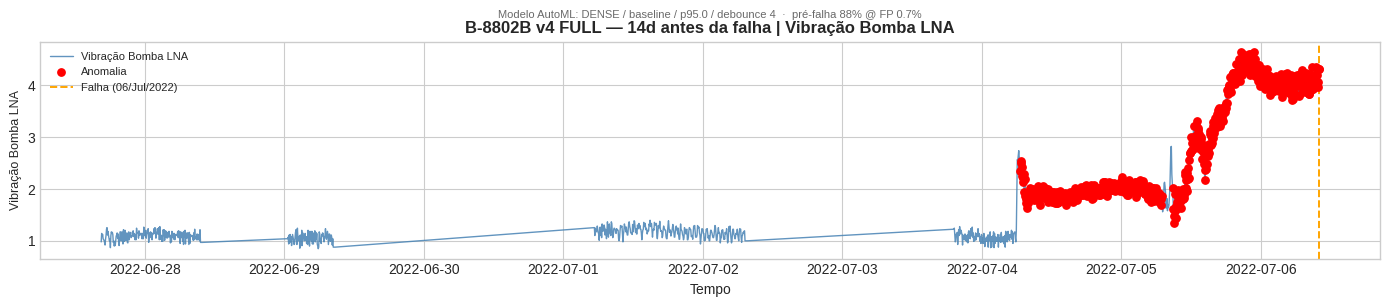

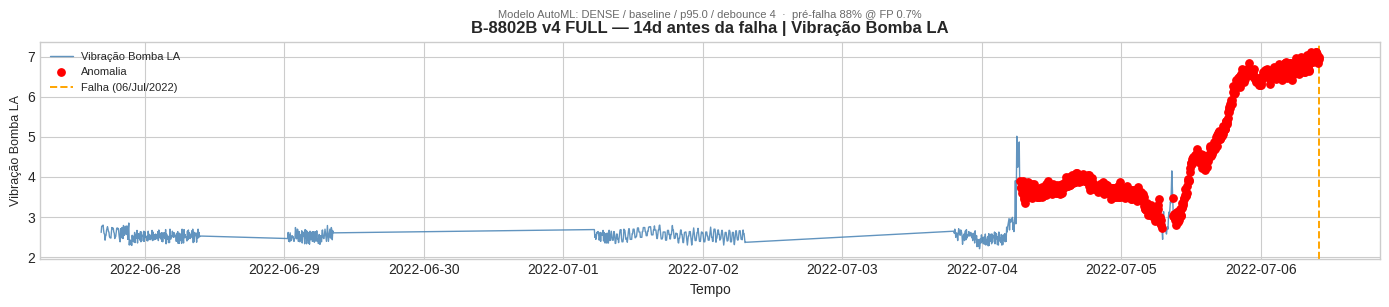

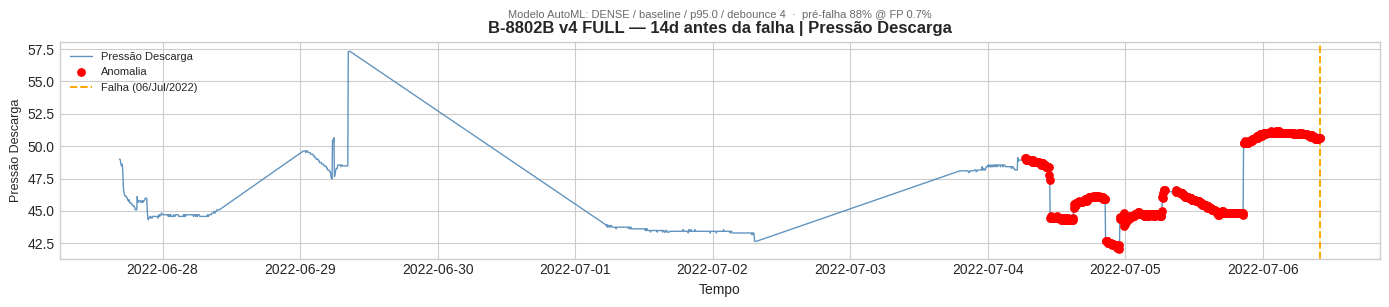

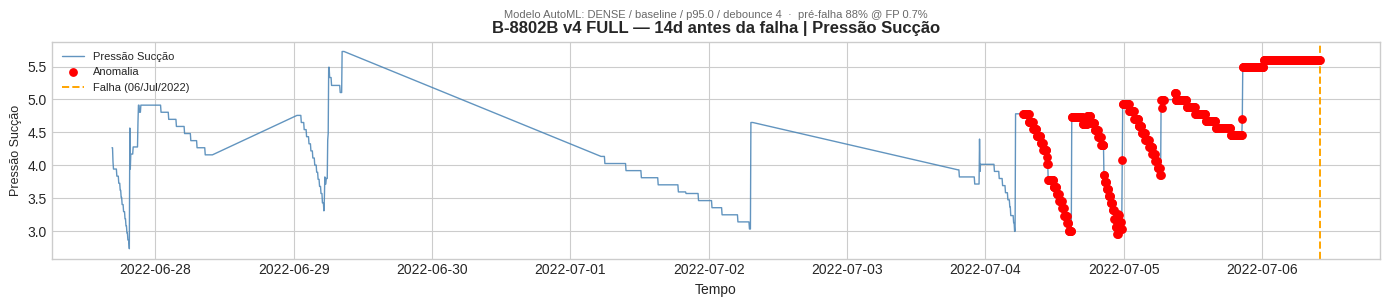

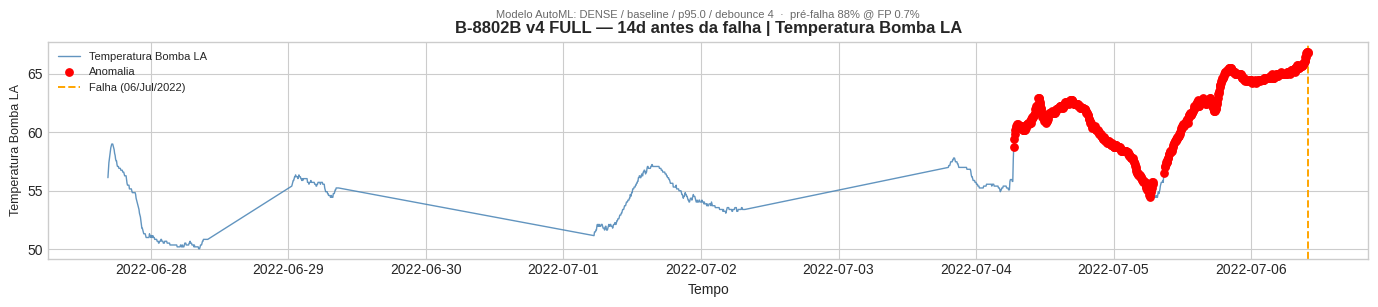

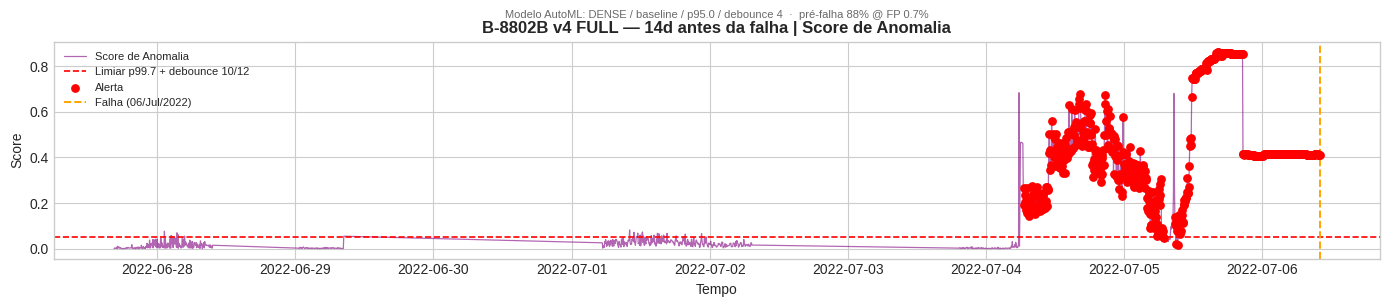

0 PNGs em /home/chico/Documentos/ciencia-dados/Transpetro-modelos/notebooks/b8802b/plots_full


In [22]:
z=EVENT_TS_F1-pd.Timedelta(days=14); dfw=df_base.loc[z:EVENT_TS_F1]; sw=scores.loc[z:EVENT_TS_F1]
common=dfw.index.intersection(sw.index); dfw,sw=dfw.loc[common],sw.loc[common]
sensors=[s for s in KEY_SENSORS if s in dfw.columns]
saved=plot_separated(dfw,sw,sensors,selected_threshold,selected_k,selected_n,EVENT_TS_F1,EVENT_LABEL_F1,PREFAILURE_DAYS,
   title_prefix=f'{EQUIPMENT_ID} v4 FULL — 14d antes da falha',tag='full_zoom14d',threshold_label=threshold_label,
   model_info=MODEL_INFO,shade=False,save=SAVE_PLOTS,outdir=OUTPUT_DIR,dpi=OUTPUT_DPI)
print(f'{len(saved)} PNGs em {OUTPUT_DIR}')

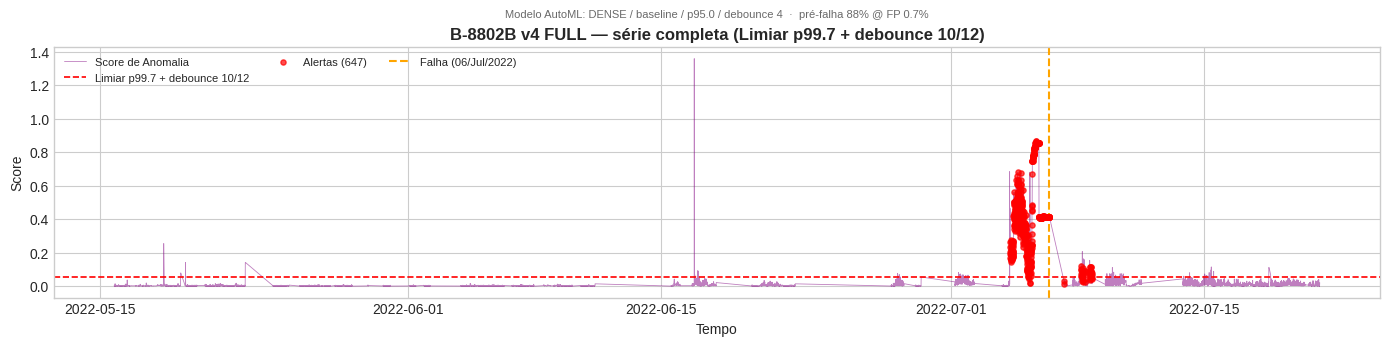

Alertas na série inteira: 647 | no começo (normal, <-20d): 0


In [23]:
# Série completa — começo da série até a falha (verificar que está limpo)
plt.style.use('seaborn-v0_8-whitegrid'); fig,ax=plt.subplots(figsize=(14,3.6)); y=scores['reconstruction_error']
fl_all=persistence_filter(y>selected_threshold, selected_k, selected_n)
ax.plot(scores.index,y,color='purple',lw=0.6,alpha=0.5,label='Score de Anomalia')
ax.axhline(selected_threshold,color='red',ls='--',lw=1.2,label=threshold_label)
idx=scores.index[fl_all]; ax.scatter(idx,y[idx],s=14,color='red',alpha=0.7,zorder=4,label=f'Alertas ({len(idx)})')
ax.axvline(EVENT_TS_F1,color='orange',ls='--',lw=1.5,label=EVENT_LABEL_F1)
ax.set_ylabel('Score'); ax.set_xlabel('Tempo'); ax.legend(loc='upper left',fontsize=8,ncol=3)
ax.set_title(f'{EQUIPMENT_ID} v4 FULL — série completa ({threshold_label})',fontweight='bold')
ax.text(0.5,1.12,MODEL_INFO,transform=ax.transAxes,ha='center',fontsize=8,color='dimgray'); fig.tight_layout()
import os
if SAVE_PLOTS: os.makedirs(OUTPUT_DIR,exist_ok=True); fig.savefig(f'{OUTPUT_DIR}/full_serie_completa.png',dpi=OUTPUT_DPI,bbox_inches='tight')
plt.show(); print(f'Alertas na série inteira: {int(fl_all.sum())} | no começo (normal, <-20d): {int(fl_all[scores.index<EVENT_TS_F1-pd.Timedelta(days=NORMAL_END_DAYS)].sum())}')